# 1. Загрузка, обработка

In [1]:
import pandas as pd
import os

In [2]:
files = [f'../data/raw/EURUSD_15min_{year}_Q{quartal}.csv'
         for year in range(2015, 2027)
         for quartal in range(1, 5)]
# оставим только существующие файлы
files = [f for f in files if os.path.exists(f)]

# Чтение и объединение
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

# Обработка времени
df['timestamp'] = pd.to_datetime(df['timestamp'],utc=False).dt.tz_localize(None)
df = df.drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

In [3]:
df.head()

,timestamp,open,high,low,close,volume
0,2014-12-31 18:00:00,1.20997,1.21070,1.20997,1.21048,1118.83
1,2014-12-31 18:15:00,1.21047,1.21079,1.21042,1.21067,523.99
2,2014-12-31 18:30:00,1.21068,1.21069,1.21000,1.21019,690.66
3,2014-12-31 18:45:00,1.21018,1.21018,1.20984,1.21010,725.78
4,2014-12-31 19:00:00,1.21010,1.21037,1.20982,1.20997,750.45


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277105 entries, 0 to 277104
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  277105 non-null  datetime64[us]
 1   open       277105 non-null  float64       
 2   high       277105 non-null  float64       
 3   low        277105 non-null  float64       
 4   close      277105 non-null  float64       
 5   volume     277105 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 12.7 MB


In [5]:
#поставим timestamp индексом
df.set_index('timestamp', inplace=True)
df.head()

,open,high,low,close,volume
timestamp,,,,,
2014-12-31 18:00:00,1.20997,1.21070,1.20997,1.21048,1118.83
2014-12-31 18:15:00,1.21047,1.21079,1.21042,1.21067,523.99
2014-12-31 18:30:00,1.21068,1.21069,1.21000,1.21019,690.66
2014-12-31 18:45:00,1.21018,1.21018,1.20984,1.21010,725.78
2014-12-31 19:00:00,1.21010,1.21037,1.20982,1.20997,750.45


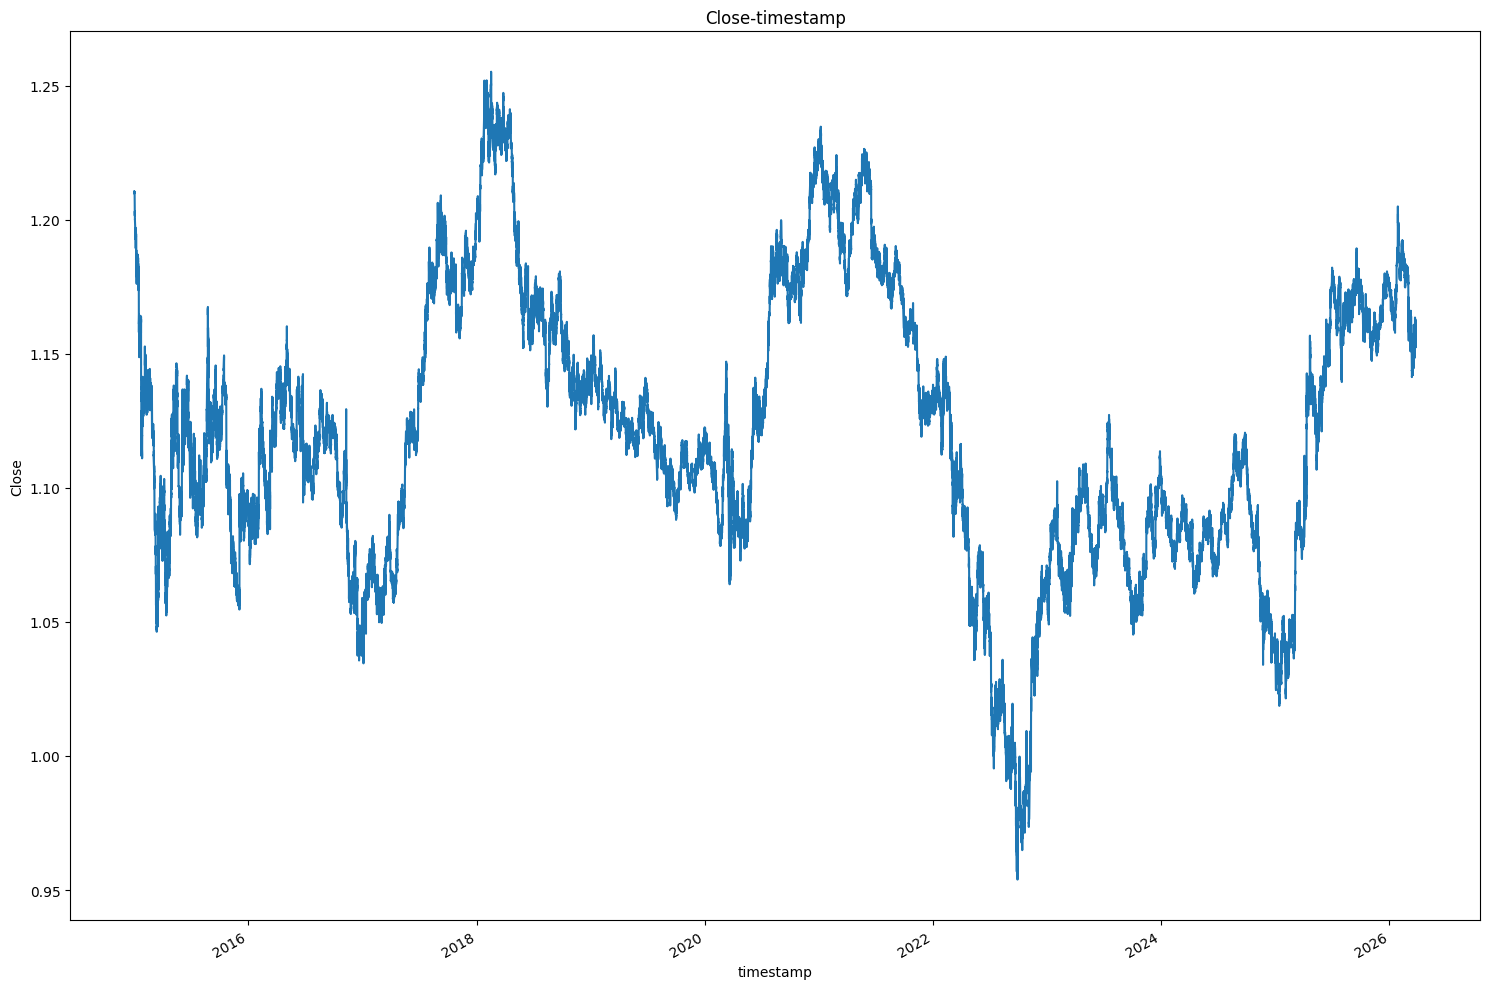

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15,10))
plt.subplots_adjust(top=1.25, bottom =1.2)

plt.subplot()
df['close'].plot()
plt.ylabel('Close')
plt.xlabel('timestamp')
plt.title('Close-timestamp')
plt.tight_layout()

# 2. 

## 2.1 Импорты 

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

#Проверка GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 2.2 Подготовка данных

In [8]:
train_df = df[df.index < '2021-01-01']
val_df = df[(df.index >= '2021-01-01') & (df.index < '2024-01-01')]
test_df = df[df.index >= '2024-01-01']

In [9]:
# масшатабирование
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_df)
scaled_val = scaler.transform(val_df)
scaled_test = scaler.transform(test_df)

# преобразование в тензоры
train_data = torch.FloatTensor(scaled_train) # хранится на cpu, чтоб gpu не был постоянно загружен. 
val_data = torch.FloatTensor(scaled_val)
test_data = torch.FloatTensor(scaled_test)
#чтоб перенести на gpu .to(device)

## 2.3 Создание последовательности

In [ ]:
# параметры для формирования последовательностей
sequence_length = 64
batch_size = 256

# для торгового робота практичнее предсказывать не абсолютную цену следующей свечи,
# а направление следующей свечи: вырастет close или нет.
# Причины выбора:
# 1) торговое решение чаще сводится к buy / sell / hold;
# 2) классификация направления обычно устойчивее, чем регрессия точной цены;
# 3) не требуется обратное масштабирование целевой переменной.
#
# Метка:
# y = 1, если close_next > close_current
# y = 0, если close_next <= close_current

# если в данных есть OHLCV, используем их как признаки(могут скачаться и доп. столбцы)
# если набор столбцов отличается, берем все доступные столбцы.
preferred_feature_columns = ['open', 'high', 'low', 'close', 'volume']
feature_columns = [col for col in preferred_feature_columns if col in train_df.columns]

if len(feature_columns) == 0:
    feature_columns = train_df.columns.tolist()

# целевой столбец для расчета направления
if 'close' in train_df.columns:
    target_column = 'close'
else:
    target_column = feature_columns[-1]
    print(f'Столбец close не найден. В качестве целевого столбца используется: {target_column}')

feature_indices = [train_df.columns.get_loc(col) for col in feature_columns]

# оставляем только нужные признаки в том порядке, который будет использоваться моделью
train_features = train_data[:, feature_indices]
val_features = val_data[:, feature_indices]
test_features = test_data[:, feature_indices]

print('Используемые признаки:', feature_columns)
print('Целевой столбец:', target_column)
print('Размер train_features:', train_features.shape)
print('Размер val_features:', val_features.shape)
print('Размер test_features:', test_features.shape)

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, feature_tensor, close_series, sequence_length):
        self.feature_tensor = feature_tensor
        self.close_values = np.asarray(close_series, dtype=np.float32)
        self.sequence_length = sequence_length

        # для последовательности длины sequence_length нужен еще 1 следующий шаг для целевой метки
        if len(self.feature_tensor) != len(self.close_values):
            raise ValueError('Длина feature_tensor и close_series должна совпадать.')

        if len(self.feature_tensor) <= self.sequence_length:
            raise ValueError('Длина ряда должна быть больше sequence_length.')

    def __len__(self):
        # количество доступных окон
        return len(self.feature_tensor) - self.sequence_length

    def __getitem__(self, idx):
        # X: окно предыдущих наблюдений
        x = self.feature_tensor[idx : idx + self.sequence_length]

        # индекс свечи, направление которой предсказываем
        target_idx = idx + self.sequence_length

        # y: направление следующей свечи относительно последней свечи в окне
        y = 1.0 if self.close_values[target_idx] > self.close_values[target_idx - 1] else 0.0
        y = torch.tensor([y], dtype=torch.float32)

        return x, y


# создаем Dataset для каждого сплита независимо, чтобы не было утечки данных через границы выборок
train_dataset = TimeSeriesDataset(
    feature_tensor=train_features,
    close_series=train_df[target_column].values,
    sequence_length=sequence_length
)

val_dataset = TimeSeriesDataset(
    feature_tensor=val_features,
    close_series=val_df[target_column].values,
    sequence_length=sequence_length
)

test_dataset = TimeSeriesDataset(
    feature_tensor=test_features,
    close_series=test_df[target_column].values,
    sequence_length=sequence_length
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print(f'Количество train-последовательностей: {len(train_dataset)}')
print(f'Количество val-последовательностей: {len(val_dataset)}')
print(f'Количество test-последовательностей: {len(test_dataset)}')

In [ ]:
# проверка размеров тензоров на одном batch
x_batch, y_batch = next(iter(train_loader))

print('Размер X batch:', x_batch.shape)   # [batch_size, sequence_length, input_size]
print('Размер y batch:', y_batch.shape)   # [batch_size, 1]

assert x_batch.ndim == 3, 'X должен иметь размерность [batch_size, sequence_length, input_size]'
assert y_batch.ndim == 2, 'y должен иметь размерность [batch_size, 1]'
assert x_batch.shape[1] == sequence_length, 'Вторая размерность X должна быть равна sequence_length'
assert x_batch.shape[2] == len(feature_columns), 'Третья размерность X должна совпадать с числом признаков'

print('Проверка размеров пройдена успешно.')

## 2.4 Создание модели GRU 

In [ ]:
# параметры модели и обучения
input_size = len(feature_columns)
hidden_size = 128
num_layers = 2
dropout = 0.2
num_epochs = 50
learning_rate = 1e-3
patience = 7

# выбор устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Используемое устройство:', device)

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()

        # dropout внутри GRU работает только если num_layers > 1
        gru_dropout = dropout if num_layers > 1 else 0.0

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout
        )

        # финальный слой выдает 1 логит для бинарной классификации направления
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch_size, sequence_length, input_size]
        out, _ = self.gru(x)

        # берем выход только по последнему шагу последовательности
        out = out[:, -1, :]  # [batch_size, hidden_size]
        out = self.fc(out)   # [batch_size, 1]

        return out


model = GRUModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout
).to(device)

print(model)

# итоговая архитектура модели
print('\nАрхитектура модели:')
print(f'input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}, dropout={dropout}')

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

best_val_loss = float('inf')
early_stopping_counter = 0
train_losses = []
val_losses = []

model_save_path = 'gru_model_best.pth'
scaler_save_path = 'gru_scaler.pkl'

In [ ]:
import pickle

for epoch in range(num_epochs):
    # =========================
    # обучение
    # =========================
    model.train()
    running_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * x_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # =========================
    # валидация
    # =========================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            running_val_loss += loss.item() * x_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(
        f'Epoch [{epoch + 1}/{num_epochs}] | '
        f'train_loss: {epoch_train_loss:.6f} | '
        f'val_loss: {epoch_val_loss:.6f}'
    )

    # =========================
    # early stopping + сохранение лучших весов
    # =========================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        early_stopping_counter = 0

        # сохраняем лучшие веса модели
        torch.save(model.state_dict(), model_save_path)

        # отдельно сохраняем scaler, чтобы потом использовать его в торговом роботе
        with open(scaler_save_path, 'wb') as f:
            pickle.dump(scaler, f)

        print(f'  -> Найдена лучшая модель. Веса сохранены в: {model_save_path}')
    else:
        early_stopping_counter += 1
        print(f'  -> Улучшения нет. Счетчик early stopping: {early_stopping_counter}/{patience}')

        if early_stopping_counter >= patience:
            print('Early stopping сработал. Обучение остановлено.')
            break

print(f'\nЛучшее значение val_loss: {best_val_loss:.6f}')
print(f'Путь к сохраненным весам: {model_save_path}')
print(f'Путь к сохраненному scaler: {scaler_save_path}')

In [ ]:
# загрузка лучших сохраненных весов обратно в модель
loaded_model = GRUModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout
).to(device)

loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))
loaded_model.eval()

with open(scaler_save_path, 'rb') as f:
    loaded_scaler = pickle.load(f)

print('Лучшие веса и scaler успешно загружены обратно.')

In [ ]:
# пример инференса на новых данных
# берем последнюю последовательность из test-части
last_sequence = test_features[-sequence_length:].unsqueeze(0).to(device)

print('Размер last_sequence:', last_sequence.shape)  # [1, sequence_length, input_size]

loaded_model.eval()
with torch.no_grad():
    logits = loaded_model(last_sequence)
    probability_up = torch.sigmoid(logits).item()
    predicted_class = 1 if probability_up >= 0.5 else 0

print(f'Вероятность роста следующей свечи: {probability_up:.6f}')
print(f'Предсказанный класс: {predicted_class}')
print('Интерпретация: 1 = следующая свеча вверх, 0 = следующая свеча вниз или без роста')

# так как модель предсказывает направление, обратное масштабирование результата не требуется.
# однако для удобства можно получить последнее фактическое значение close в исходном масштабе.
last_close_original = test_df[target_column].iloc[-1]
print(f'Последнее доступное значение {target_column} в исходном масштабе: {last_close_original}')

In [ ]:
# пример вспомогательной функции для интеграции в торгового робота
# на вход подается DataFrame с теми же столбцами, что использовались при обучении.
def predict_next_candle_direction(recent_df, model, scaler, feature_columns, sequence_length, device):
    if len(recent_df) < sequence_length:
        raise ValueError(f'Для прогноза нужно минимум {sequence_length} строк.')

    # берем только нужные признаки и сохраняем порядок столбцов
    model_input_df = recent_df[train_df.columns].copy()

    # применяем тот же scaler, который использовался на обучении
    scaled_recent = scaler.transform(model_input_df)
    scaled_recent = torch.FloatTensor(scaled_recent)

    # оставляем только признаки, которые реально подаются в модель
    feature_indices = [train_df.columns.get_loc(col) for col in feature_columns]
    scaled_recent = scaled_recent[:, feature_indices]

    # берем последнее окно
    sequence = scaled_recent[-sequence_length:].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(sequence)
        probability_up = torch.sigmoid(logits).item()
        predicted_class = 1 if probability_up >= 0.5 else 0

    return {
        'probability_up': probability_up,
        'predicted_class': predicted_class,
        'signal': 'BUY' if predicted_class == 1 else 'SELL'
    }


# пример вызова функции
example_result = predict_next_candle_direction(
    recent_df=test_df.tail(sequence_length + 10),
    model=loaded_model,
    scaler=loaded_scaler,
    feature_columns=feature_columns,
    sequence_length=sequence_length,
    device=device
)

print('Пример результата для торгового робота:', example_result)
print(f'Итоговый путь к сохраненным весам: {model_save_path}')